In [1]:
from lib import OSN
from lib import readout
from lib import plots
from lib import epl as EPL
import time
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
import os.path
from os import path
from numpy.matlib import repmat
%matplotlib inline
from preprocess import preprocessing as pre
from sklearn.decomposition import PCA


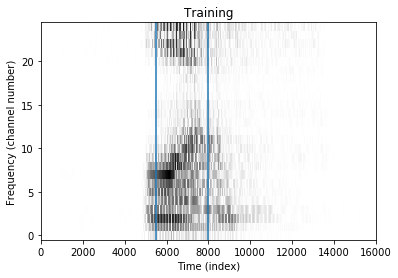

In [2]:

testSounds = ["0a196374_nohash_1"]
trainingSounds = ["0a196374_nohash_1"]

cfN = 25    #this is typically 50, but due to 50 testAudio, we lowered 
scale = 15  #changed because we're normalising in a different way
#I changed scale from 15 to 10 because 16 resulted in a KeyError: 21
# normalising 0 to 1, then multiply by scale (15)
# this is to scale each individual sample

trainingSpect = pre.spectArray(trainingSounds[0], cfN=cfN)
t_start = 5000
t_end = 10000
t_step = 100 #decrease bc too course

trainingIndex = [5500,8000]  #attempt with single trainingIndex
#was 5500, 7000
testingIndex = [x for x in range(t_start,t_end,t_step)] #[5000;10000;100]
range_f = 100 
step_f = 20    #used to be 10, but we are using coarser signals to speed computation
#range in times of frequencies
lenTraining = len(trainingSounds) * len(trainingIndex)
lenTest = len(testSounds) * len(testingIndex) + lenTraining
#testing set includes the testing set so we can see the best performance of trained vs trained

pre.spectShow(trainingSpect)
plt.title("Training")
plt.axvline(x=trainingIndex[0])
plt.axvline(x=trainingIndex[1])



for i in range(len(testAudio)):
    print(testAudio[i])

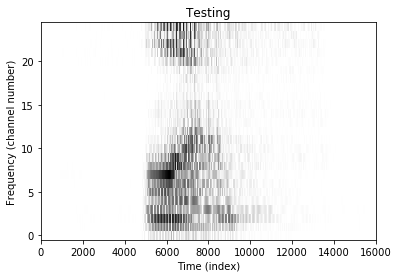

In [3]:
colors = ['y','k','b','y','k','b','y','k','b','y']

for sound in trainingSounds:
    for i in trainingIndex:
        if i == trainingIndex[0]:
            originaltrainingAudio = pre.selectSound(pre.spectArray(sound, cfN=cfN), range_f, step_f, i);
        else:
            originaltrainingAudio = np.concatenate((originaltrainingAudio, pre.selectSound(pre.spectArray(sound,cfN=cfN), range_f, step_f, i)))

originaltestAudio = np.array([])


testingSpect = pre.spectArray(testSounds[0], cfN=cfN)  #pull out of the loop (before loop)
pre.spectShow(testingSpect)
plt.title("Testing")

for index in testingIndex: #index in testingIndex
   # plt.axvline(x=index, c=colors[testingIndex.index(index)])
    
    if originaltestAudio.shape[0] == 0:
        originaltestAudio = pre.selectSound(testingSpect, range_f, step_f, index)
    else:
        originaltestAudio = np.concatenate((originaltestAudio,pre.selectSound(testingSpect, range_f, step_f, index)))


In [4]:
min(originaltestAudio.shape)
#testAudio = originaltestAudio
#trainingAudio = originaltrainingAudio

50L

In [5]:
pca = PCA(n_components = min(originaltestAudio.shape), whiten = False)
# min(originaltestAudio.shape) descripes the highest possible value of n_components for PCA
pca.fit(originaltestAudio)
trainingAudio = pca.transform(originaltrainingAudio)
testAudio = pca.transform(originaltestAudio)
trainingAudio = pre.rescaleInput(trainingAudio, scale)
testAudio = pre.rescaleInput(testAudio, scale)

In [6]:
from lib import epl
nGammaPerTraining = 5
nGammaPerSound = 5
#both vars were 10
print("Number of sounds to train = " + str(len(trainingAudio))); 
print("Number of sounds to test = " + str(len(testAudio))); 


Number of sounds to train = 2
Number of sounds to test = 50


Training sound 1
Training sound 2
10 sounds tested
20 sounds tested
30 sounds tested
40 sounds tested
50 sounds tested
Simulation Duration = 0.365000009537s
Training sound 1
Training sound 2
10 sounds tested
20 sounds tested
30 sounds tested
40 sounds tested
50 sounds tested
Simulation Duration = 8.8069999218s
Training sound 1
Training sound 2
10 sounds tested
20 sounds tested
30 sounds tested
40 sounds tested
50 sounds tested
Simulation Duration = 27.4000000954s


<function matplotlib.pyplot.show>

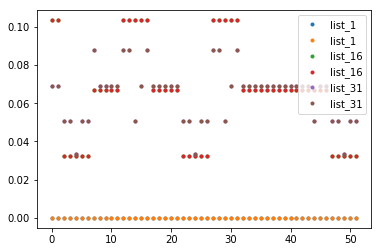

In [7]:
l = range(1,50,5)
#l.append(0.7)
l.append(50)
l.sort()

correctness = []
sim_times = []
SImatrices = []

GCsPerNeurogenesis = 5; 
l=l[0:9:3]
for n_components in l:
    #Network initialization
    nMCs = n_components; 
    nGCs = nMCs*GCsPerNeurogenesis*lenTraining;     #every MC has 5 GCs per sound  
    net = EPL.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

    #Sniff
    def sniff(sound, learn_flag=0, nGammaPerSound=5, gPeriod=40):
        sensorInput = OSN.OSN_encoding(sound); 
        for j in range(0, nGammaPerSound):
            for k in range(0, gPeriod): 
                net.update(sensorInput, learn_flag=learn_flag);
                pass; 
        net.reset(); 

    #Training
    t1 = time.time(); 
    for i in range(0, lenTraining):
        print("Training sound " + str(i+1)) 
        sniff(trainingAudio[i,:n_components], learn_flag=1,nGammaPerSound = nGammaPerTraining); 
        # changed nGammaPerSound from 5 to 10
        net.GClayer.invokeNeurogenesis();
        sniff(trainingAudio[i,:n_components], learn_flag=0, nGammaPerSound = nGammaPerSound);

    #added this for loop to change structure of net.gammaCode
    for i in range(0, lenTraining):
        sniff(trainingAudio[i,:n_components], learn_flag=0, nGammaPerSound = nGammaPerSound);

    #Testing
    for i in range(0, lenTest-lenTraining):
        #checking only the Test audio, and not the tested with trained
        sniff(testAudio[i,:n_components], learn_flag=0, nGammaPerSound = nGammaPerSound); 
        if((i+1)%10==0 and (i+1)!=0):
            print(str(i+1) + " sounds tested"); 
    t2 = time.time(); 
    print("Simulation Duration = " + str(t2-t1) + "s")
    sim_time = t2-t1
    sim_times.append(sim_time)

    ## epl gammaCode parsing

    #Remember the first training loop uses nGammaPerSound = 10

    gammaCode_size = lenTraining*(nGammaPerTraining + nGammaPerSound) + lenTest * nGammaPerSound
#    (gammaCode_size,len(net.gammaCode))

#    (len(net.gammaCode[lenTraining*nGammaPerTraining:lenTraining*(nGammaPerTraining+nGammaPerSound)]),len(net.gammaCode[lenTraining*nGammaPerTraining:lenTraining*(nGammaPerTraining+nGammaPerSound)][0]))

#    (nGammaPerSound, lenTraining, -1)

    #trained = np.array(net.gammaCode[lenTraining*nGammaPerTraining:lenTraining*(nGammaPerTraining+nGammaPerSound)]).reshape(nGammaPerSound, lenTraining, -1)
    #put lenTest/nGammaPerSound into another variable
   # tested = np.array(net.gammaCode[lenTraining*(nGammaPerTraining+nGammaPerSound):]).reshape(nGammaPerSound, lenTest, -1)
   
    
    trained = np.array(net.gammaCode[lenTraining*(nGammaPerTraining+nGammaPerSound):lenTraining*(nGammaPerTraining+2*nGammaPerSound)]).reshape(nGammaPerSound, lenTraining, -1)
    tested = np.array(net.gammaCode[lenTraining*(nGammaPerTraining+nGammaPerSound):]).reshape(nGammaPerSound, lenTest, -1)
#   There's an overlap between trained and tested in that tested contains trained
#   
    
#     sniff --> neurogenesis --> sniff
#     then sniff in separate loop without learning
    
#     trained replace with nGammaPerTraining+nGammaPerSound
#     tested begins where trained ends
    
#     think about creating seperate variables (ex: training_start and training_end) to make code understandable


    true_negative = 0
    false_positive = 0


    SImatrix = np.zeros((lenTraining, lenTest), dtype =float)  
    for i in range(0, len(trained[-1])):
        for j in range(0, len(tested[-1])):
            SImatrix[i][j] = (pre.computeSimilarity(trained[-1][i], tested[-1][j]))
            #index -1 is the last activation of the gamma cycle which is the most different one
#    decisionMatrix = (SImatrix> 0.75)
    
    #for j in range(0, len(tested[-1])):
    #    print(tested[-1][2]==tested[-1][j])
    
#designing truth Table
# move to before loop
#truthTable = np.tile([True, False], (lenTest,1)).T

#    pre.results(decisionMatrix,truthTable)

    plt.plot(range(0,SImatrix.shape[1]) , SImatrix.T, ".", label='list_%s' %n_components) #make legend for colors and n_components
    SImatrices.append(SImatrix)
plt.legend()
plt.show

In [13]:
np.zeros((lenTraining, lenTest), dtype =float)  

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.]])

In [9]:
SImatrix.shape[1]

52L

In [10]:
l

[1, 16, 31]

In [11]:
sim_times

[0.36500000953674316, 8.806999921798706, 27.40000009536743]

In [12]:
SImatrices

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]]),
 array([[0.1034, 0.1034, 0.0323, 0.0323, 0.0323, 0.0323, 0.0323, 0.0667,
         0.0667, 0.0667, 0.0667, 0.0667, 0.1034, 0.1034, 0.1034, 0.1034,
         0.1034, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0323, 0.0323,
         0.0323, 0.0323, 0.0323, 0.1034, 0.1034, 0.1034, 0.1034, 0.1034,
         0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667,
         0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0323,
         0.0323, 0.0323, 0.0323, 0.0323],
        [0.1034, 0.1034, 0.0